In [1]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import numpy as np

In [3]:
from tensorflow import keras

In [3]:
fmnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fmnist.load_data()

In [5]:
(X_train, y_train),(X_test, y_test) =fmnist.load_data()
assert X_train.shape ==(60000, 28,28)
assert X_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

In [12]:
# summerize loaded data
print('Train: X=%s, y=%s' % (str(X_train.shape),str(y_train.shape)))
print('Test: X=%s, y=%s' % (str(X_test.shape), str(y_test.shape)))

Train: X=(60000, 28, 28), y=(60000,)
Test: X=(10000, 28, 28), y=(10000,)


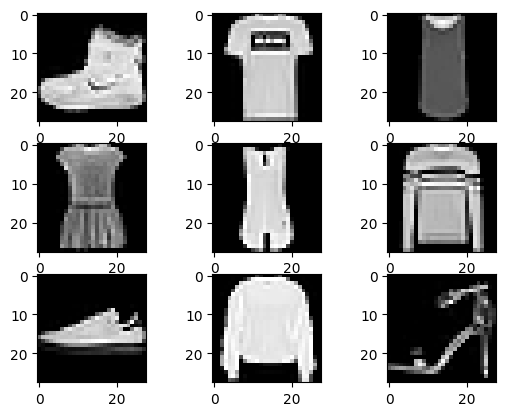

In [23]:
# plot first few images
import matplotlib.pyplot as plt 
for i in range(9):
    # define subplot
    plt.subplot(330 + 1 + i)
    # plot raw pixel data
    plt.imshow(X_train[i], 
cmap=plt.get_cmap('gray'))
# show the figure 
plt.show()

In [24]:
# preprocess the data
X_train = X_train / 255.0
X_test = X_test / 255.0


In [29]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

c:\Users\AD\.conda\envs\tf_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
# compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# train the model 
model.fit(X_train, y_train, epochs=5)

# evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7843 - loss: 0.6248
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8627 - loss: 0.3866
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8770 - loss: 0.3356
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8859 - loss: 0.3103
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8946 - loss: 0.2903
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8724 - loss: 0.3437
Test accuracy: 0.8741999864578247


In [34]:
# make predictions wih the model
predictions = model.predict(X_test)
# print the shape of the predictions array
print(predictions.shape)
# print the first ten predictions 
print(predictions[:10])
# convert the prediction to class labels
class_labels = [tf.argmax(prediction) for prediction in predictions]
# print the first ten class labels
print(class_labels[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 10)
[[5.87491002e-07 7.40279349e-09 4.72834529e-07 4.04574121e-06
  3.59432676e-07 2.33172020e-03 8.82707980e-07 1.04203776e-01
  1.25564575e-05 8.93445492e-01]
 [3.40621082e-05 8.35936653e-09 9.77168083e-01 6.12974816e-07
  8.20036978e-03 2.37371268e-11 1.45967985e-02 9.68097889e-13
  2.96197751e-08 2.62724027e-11]
 [1.60725815e-08 9.99999762e-01 1.17617505e-09 1.30528804e-07
  1.11337151e-07 2.22938814e-13 6.48137810e-09 6.55481994e-15
  2.71646372e-10 2.64892614e-14]
 [2.75356683e-07 9.99979377e-01 6.42249205e-08 1.86882626e-05
  1.17938873e-06 6.24137825e-11 3.90267786e-07 9.64063464e-13
  3.16388782e-09 9.65054564e-11]
 [2.49585301e-01 3.10777104e-05 3.27291228e-02 5.01998980e-03
  3.70158590e-02 2.90423595e-05 6.74327552e-01 9.99800886e-06
  1.18013192e-03 7.18774463e-05]
 [1.34458705e-05 9.99960303e-01 1.23473535e-06 4.30943601e-06
  1.18033240e-05 1.87145943e-09 8.83526081e-06 7.83260262e-12
  6.04419981e-08 2.03117675e-10]
 [9.5

c:\Users\AD\.conda\envs\tf_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7769 - loss: 0.6550 - val_accuracy: 0.8584 - val_loss: 0.4066
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8623 - loss: 0.3846 - val_accuracy: 0.8676 - val_loss: 0.3598
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8730 - loss: 0.3443 - val_accuracy: 0.8764 - val_loss: 0.3333
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8846 - loss: 0.3120 - val_accuracy: 0.8814 - val_loss: 0.3227
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8906 - loss: 0.2952 - val_accuracy: 0.8786 - val_loss: 0.3388


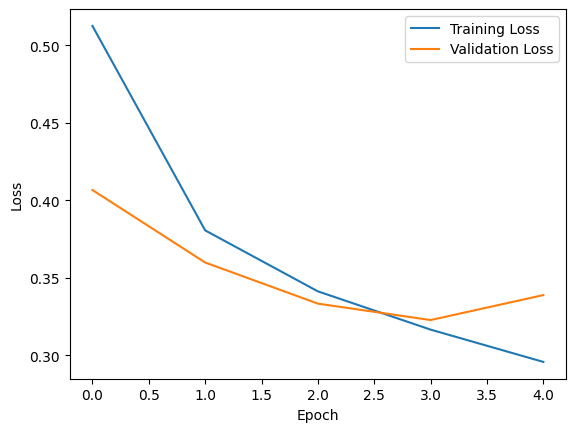

In [35]:
import tensorflow as tf
import matplotlib.pyplot as plt
# load the fashion mnist dataset
(X_train, y_train),(X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# preprocess the data
X_train = X_train / 255.0
X_test = X_test / 255.0
# split the training data into training and validation set
X_val = X_train[:5000]
y_val = y_train[:5000]
X_train = X_train[5000:]
y_train = y_train[5000:]
# build the model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])
# compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# train the model 
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val))
# plot the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()



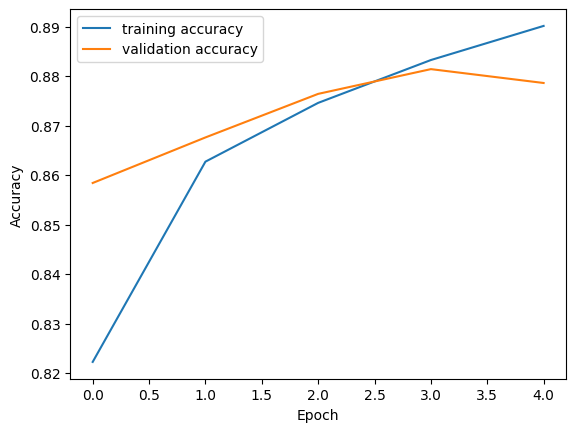

In [36]:
# plot the training and validation accuracy
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()